
# Tutorial 3: Spec Contracts and Debugging

Estimated time: 30-40 minutes

## Prerequisites
No optional backends required. The two figures need matplotlib, which ships in the
`[tutorials]` extra (`pip install -e '.[tutorials]'`).

## Learning aims
- Primary package aim: debug validation failures and restore a valid spec
- Secondary scientific aim: understand what a spec contract does and does *not* protect,
  and why `support` is a scientific claim rather than a guard rail

## Success criteria
- you can intentionally break and repair a spec using validator output
- you can name at least one contract `bayesmm validate` does **not** check, and say what
  its silence costs you



## Why this tutorial matters

**A spec is a contract, and the first job of this tutorial is to find out exactly how much
of that contract is machine-enforced.**

When `bayesmm validate` exits `0`, `ModelSpec.model_validate` has confirmed a specific,
finite list of things:

- **every required section and field is present** — `schema_version`, `model`, `runner`,
  `io_schema`, `design`, `adapter`, `reproducibility`, `storage`;
- **every value has the declared type** — `units` is a string, `cpus` is an int,
  `strategy` is one of `grid` / `sobol`;
- **per-field constraints hold** — `support[1] > support[0]`, `cpus >= 1`, `seed >= 0`,
  `storage.root` is project-relative with no `..` traversal;
- **per-section conditionals hold** — `design.grid` exists when `strategy` is `grid`,
  `model.artifact.entrypoint` exists when the artifact `type` is `local`, a mapping
  carries exactly one of `to` / `from`;
- **nothing else is present** — every spec model sets `extra="forbid"`, so `desgin` is a
  loud error rather than a silently ignored key.

That is the whole list. What is *not* on it is the part worth memorizing:

> **Validation is per-section.** Nothing checks that the variable names in `design.grid`,
> in `io_schema.inputs[*].name` and in `adapter.input_mapping[*].var` agree with each
> other. Nothing checks that `design.grid` values fall inside the declared `support`.
> Nothing checks that `adapter.id` names an adapter that exists. `ModelSpec` has no
> cross-section validator at all — read `src/bayesian_metamodeling/spec/modelspec.py` and
> you will find every validator scoped inside a single sub-model. Those cross-section
> contracts are real, and the framework breaks without them; they are simply enforced by
> nobody but you.

So this notebook runs **two break/repair cycles the validator catches** — a missing
section and a violated per-field constraint — and then **two breaks it does not catch**,
where you get to watch how far a bad spec travels before anything complains. The first
kind of bug costs you seconds. The second kind is why a framework needs a tutorial about
contracts at all.



## Setup

One bootstrap cell, identical in every tutorial: it walks up from the notebook to the repo
root, puts `src/` on `sys.path`, and `chdir`s there — so every relative path below means
the same thing no matter where you launched Jupyter from. `run_mm_cli` then calls the
`bayesmm` CLI **in process** and returns its exit code, which is what lets a tutorial
trigger failures on purpose without a shell.


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barak/git/metamodeling



## The map: anatomy of a `ModelSpec`

Keep this picture in view while you debug. `ModelSpec` has **eight** top-level fields, and
every validation error you will meet names one of them as the first element of its path.
The figure gives each block what it is responsible for, plus one error that block really
raises — each red line is a message that exists verbatim in
`src/bayesian_metamodeling/spec/modelspec.py`.

The dashed arrows are the part to remember. They are contracts the framework genuinely
depends on and **never checks**: one variable name has to appear identically in three
places, and if it does not, `validate` still says yes.


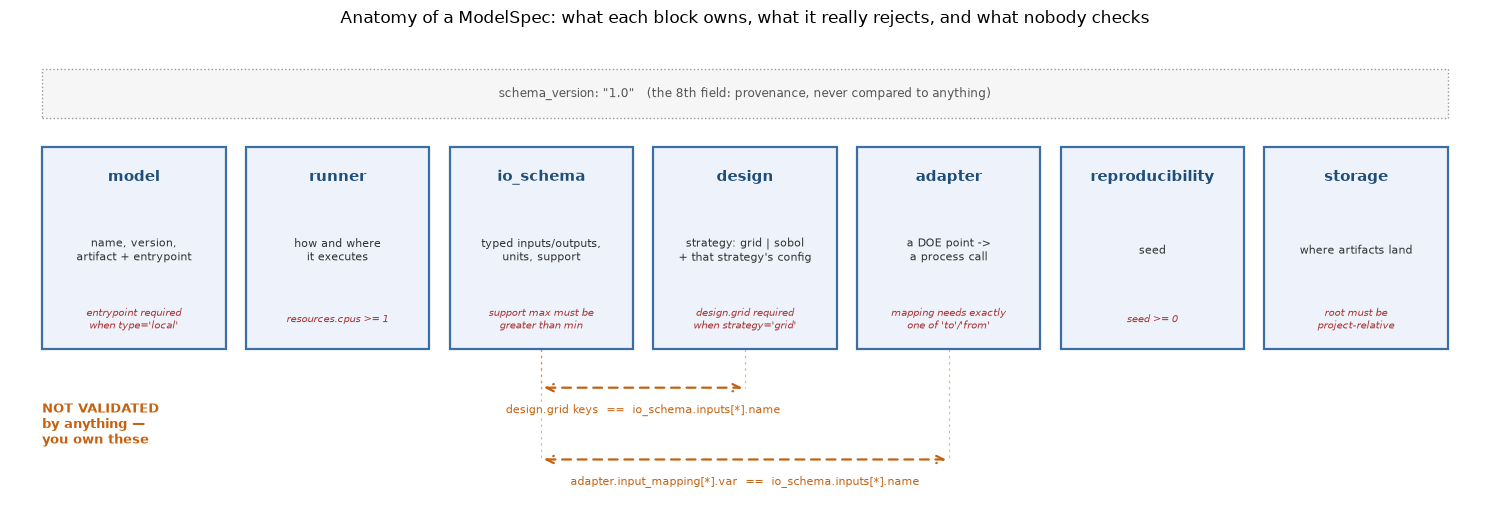

Red   = a validation error that block really raises (verbatim from modelspec.py).
Dashed orange = a contract the framework RELIES on and NEVER validates.
Not drawable at all: `adapter.id` is a bare non-empty string, so an unknown id
passes validation and only fails at RUN time, in adapters/registry.py.


In [2]:

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

# One box per top-level ModelSpec field, in declaration order
# (src/bayesian_metamodeling/spec/modelspec.py::ModelSpec). `schema_version` is the
# eighth field; it is a bare string, so it gets a tag rather than a box.
BLOCKS = [
    ("model", "name, version,\nartifact + entrypoint", "entrypoint required\nwhen type='local'"),
    ("runner", "how and where\nit executes", "resources.cpus >= 1"),
    ("io_schema", "typed inputs/outputs,\nunits, support", "support max must be\ngreater than min"),
    ("design", "strategy: grid | sobol\n+ that strategy's config", "design.grid required\nwhen strategy='grid'"),
    ("adapter", "a DOE point ->\na process call", "mapping needs exactly\none of 'to'/'from'"),
    ("reproducibility", "seed", "seed >= 0"),
    ("storage", "where artifacts land", "root must be\nproject-relative"),
]

w, h, gap = 2.0, 1.75, 0.22
fig, ax = plt.subplots(figsize=(15, 5.2))

for i, (name, contains, err) in enumerate(BLOCKS):
    x = i * (w + gap)
    ax.add_patch(Rectangle((x, 1.15), w, h, facecolor="#eef3fb",
                           edgecolor="#3b6ea5", linewidth=1.6))
    ax.text(x + w / 2, 1.15 + h - 0.26, name, ha="center", va="center",
            fontsize=11, fontweight="bold", color="#1f4e79")
    ax.text(x + w / 2, 1.15 + h / 2 - 0.02, contains, ha="center", va="center",
            fontsize=8, color="#333")
    ax.text(x + w / 2, 1.15 + 0.26, err, ha="center", va="center",
            fontsize=7.5, style="italic", color="#a33")

span = len(BLOCKS) * (w + gap) - gap
ax.add_patch(Rectangle((0, 3.15), span, 0.42, facecolor="#f6f6f6",
                       edgecolor="#999", linewidth=1.0, linestyle=":"))
ax.text(span / 2, 3.36, 'schema_version: "1.0"   (the 8th field: provenance, never compared to anything)',
        ha="center", va="center", fontsize=8.5, color="#555")


def unchecked(i, j, label, y):
    """Draw a contract that spans two blocks and is enforced by nobody."""
    x0 = i * (w + gap) + w / 2
    x1 = j * (w + gap) + w / 2
    for x in (x0, x1):  # drop lines, so it is obvious WHICH blocks are tied
        ax.plot([x, x], [1.15, y], color="#c46210", linewidth=0.9, alpha=0.45,
                linestyle=(0, (2, 3)), zorder=0)
    ax.add_patch(FancyArrowPatch((x0, y), (x1, y), arrowstyle="<->", mutation_scale=13,
                                 color="#c46210", linewidth=1.6, linestyle=(0, (4, 3))))
    ax.text((x0 + x1) / 2, y - 0.22, label, ha="center", fontsize=8, color="#c46210",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5})


unchecked(2, 3, "design.grid keys  ==  io_schema.inputs[*].name", 0.82)
unchecked(2, 4, "adapter.input_mapping[*].var  ==  io_schema.inputs[*].name", 0.20)
ax.text(0.0, 0.50, "NOT VALIDATED\nby anything —\nyou own these", ha="left", va="center",
        fontsize=9, fontweight="bold", color="#c46210")

ax.set_xlim(-0.35, span + 0.35)
ax.set_ylim(-0.15, 3.85)
ax.axis("off")
ax.set_title("Anatomy of a ModelSpec: what each block owns, what it really rejects, "
             "and what nobody checks", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print("Red   = a validation error that block really raises (verbatim from modelspec.py).")
print("Dashed orange = a contract the framework RELIES on and NEVER validates.")
print("Not drawable at all: `adapter.id` is a bare non-empty string, so an unknown id")
print("passes validation and only fails at RUN time, in adapters/registry.py.")



## Predict the error before you read it

Do this twice — once before Step 1's break, once before Step 4's. It is the whole skill
T3 is trying to build, and it takes fifteen seconds.

Write down three answers:

1. **The field** you expect the validator to flag.
2. **The category**: missing field, wrong type, or failed constraint. Those are the three
   you will actually see. There is no fourth "cross-field" category in this framework —
   which is exactly what Steps 5 and 6 are about.
3. **The path** the error will report — the dotted route from the top of the spec down to
   the offending field. Guess how *deep* it goes.

Then compare. The reason to guess first: Pydantic errors are *structured*, so once you can
predict their shape you stop reading them top to bottom and start jumping straight to the
path. That is the difference between debugging a spec in ten seconds and in ten minutes.

**Rule of thumb: read the path, then the message.** The CLI prints exactly one line per
error, `- <path>: <message>`, from `format_validation_error` in `spec/modelspec.py`. It
throws away Pydantic's machine-readable `type` field; if you want it, call
`ModelSpec.model_validate` yourself and inspect `exc.errors()` — the wrong-kind-of-spec
cell near the end of this notebook does exactly that, and so does the self-check.



## Step 1: Break it structurally — remove a required section

We work on a scratch copy, never on the shipped spec. The break: delete `design.grid` from
a spec whose `design.strategy` is `"grid"`.

Predict first (the three questions above).


In [3]:

import json

# `root` came from bootstrap() above — no need to re-derive it in every cell.
SPEC_SRC = root / "tutorials/specs/model.toy.grid.json"
SPEC = root / "tmp/tutorials_modelspec_edit.json"
SPEC.parent.mkdir(parents=True, exist_ok=True)
SPEC.write_text(SPEC_SRC.read_text())

payload = json.loads(SPEC.read_text())
removed = payload["design"].pop("grid", None)
SPEC.write_text(json.dumps(payload, indent=2))

print("Scratch copy :", SPEC.relative_to(root))
print("Removed      : design.grid =", removed)
print("design is now:", payload["design"])


Scratch copy : tmp/tutorials_modelspec_edit.json
Removed      : design.grid = {'a': [0.0, 1.0, 2.0], 'b': [0.0, 1.0, 2.0]}
design is now: {'strategy': 'grid'}



## Step 2: Validate, and read the path first


In [4]:

rc_missing_grid = run_mm_cli("validate", "tmp/tutorials_modelspec_edit.json", check=False)
print("exit code:", rc_missing_grid)


$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation failed:
- design: Value error, design.grid is required when design.strategy is 'grid'
exit code: 1



**What you just saw**, verbatim:

```
$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation failed:
- design: Value error, design.grid is required when design.strategy is 'grid'
exit code: 1
```

Two things to notice, and neither is the obvious one.

**The path is `design`, not `design.grid`.** The rule lives in a
`model_validator(mode="after")` on `DesignSpec`, and a model validator's error is
attributed to the *model*, not to a field inside it — a key that is missing has no field of
its own to be blamed on. So whenever a path stops at a section name instead of reaching a
leaf, look for a whole-section rule rather than hunting for a typo in a field called
`design`.

**The message is a sentence a human wrote.** `design.grid is required when
design.strategy is 'grid'` is a `ValueError` raised inside `DesignSpec.check_strategy_config`.
Contract errors in this framework read like contract clauses because they were written by
hand; shape errors (`Input should be a valid string`) come from Pydantic itself and read
like it. The wording tells you which kind you are looking at.



## Step 3: Repair and re-validate


In [5]:

payload = json.loads(SPEC.read_text())
payload["design"]["grid"] = {"a": [0.0, 1.0, 2.0], "b": [0.0, 1.0, 2.0]}
SPEC.write_text(json.dumps(payload, indent=2))
print("Restored design.grid =", payload["design"]["grid"])


Restored design.grid = {'a': [0.0, 1.0, 2.0], 'b': [0.0, 1.0, 2.0]}



**Expected output**, verbatim:

```
$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
exit code: 0
```

Now read what that success line does **not** say. There is no design-point count, because
`validate` never plans the DOE: it loads the JSON, hands it to `ModelSpec.model_validate`,
and prints three fields off the resulting object (`_validate_command` in `cli/main.py`).

"Structurally valid" and "produces a sane, non-empty design" are two different questions.
The second one is answered by `bayesmm plan`, and Step 6 is built on the gap between them.


In [6]:

rc_repair_grid = run_mm_cli("validate", "tmp/tutorials_modelspec_edit.json", check=False)
print("exit code:", rc_repair_grid)


$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
exit code: 0



## Step 4: A second error family — a per-field constraint

Step 1 broke the spec **structurally**: a required key was gone. This break is different.
The spec stays structurally perfect — every section present, every type correct — and we
violate a constraint on a *single field's value*: invert a `support: [min, max]` range to
`[max, min]`.

It is an easy typo, and no amount of shape checking would catch it, because `[2.0, 0.0]` is
a perfectly good list of two floats. Predict again — especially question 3, how deep the
path goes this time.


In [7]:

payload = json.loads(SPEC.read_text())

# Inject the bug: invert the support range on the first input from [0.0, 2.0] to
# [2.0, 0.0]. The list still holds two numbers, so it is structurally a valid
# `support` field — but min > max is contractually broken.
payload["io_schema"]["inputs"][0]["support"] = [2.0, 0.0]
SPEC.write_text(json.dumps(payload, indent=2))

print("Wrote spec with inverted support:", SPEC.relative_to(root))
print(
    "io_schema.inputs[0]:",
    payload["io_schema"]["inputs"][0]["name"],
    "support =",
    payload["io_schema"]["inputs"][0]["support"],
)


Wrote spec with inverted support: tmp/tutorials_modelspec_edit.json
io_schema.inputs[0]: a support = [2.0, 0.0]


In [8]:

rc_inverted_support = run_mm_cli("validate", "tmp/tutorials_modelspec_edit.json", check=False)
print("exit code:", rc_inverted_support)


$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation failed:
- io_schema.inputs.0.support: Value error, support max must be greater than support min
exit code: 1



**What you just saw**, verbatim:

```
$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation failed:
- io_schema.inputs.0.support: Value error, support max must be greater than support min
exit code: 1
```

Read the path before the message: `io_schema.inputs.0.support` is "the `support` field of
the entry at index 0 of `io_schema.inputs`". Every element of the route is there, right
down to the list index.

**Contrast it with Step 1 and you have the whole tell.** Step 1's path stopped at
`design`; this one runs all the way to a leaf. That is not cosmetic — it tells you which
kind of rule fired. `check_support` is a `field_validator` on `support`, so Pydantic knows
precisely which field to blame. `check_strategy_config` is a `model_validator` on the whole
`DesignSpec`, so it can only blame the section. Path depth is a diagnosis, not decoration.


In [9]:

payload = json.loads(SPEC.read_text())

# Repair: swap the bounds back to (min, max).
payload["io_schema"]["inputs"][0]["support"] = [0.0, 2.0]
SPEC.write_text(json.dumps(payload, indent=2))

rc_repair_support = run_mm_cli("validate", "tmp/tutorials_modelspec_edit.json", check=False)
print("exit code:", rc_repair_support)


$ bayesmm validate tmp/tutorials_modelspec_edit.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
exit code: 0



## Step 5: A break the validator does **not** catch

Both cycles so far ended in a red line and exit code `1` — the cheapest failure there is.
Now the interesting case, and the one you will actually meet.

Copy the repaired spec and rename exactly **one** key: `design.grid`'s `a` becomes `alpha`.
Leave `io_schema.inputs[0].name` and `adapter.input_mapping[0].var` as `a`. That is one
character of carelessness, and it makes the three places that must agree about this
variable's name disagree.

**Predict, before you run:** does `bayesmm validate` pass or fail? What about
`bayesmm plan`? What about `bayesmm run` — and if it fails, *when* does it fail?


In [10]:

MISMATCH = root / "tmp/tutorials_modelspec_mismatch.json"

payload = json.loads(SPEC.read_text())
grid = payload["design"]["grid"]
payload["design"]["grid"] = {"alpha": grid["a"], "b": grid["b"]}   # the whole bug
# Keep this experiment's artifacts out of the store T1/T5 use.
payload["storage"]["root"] = "tmp/tutorials/t3_mismatch_store"
MISMATCH.write_text(json.dumps(payload, indent=2))

print("io_schema.inputs names    :", [v["name"] for v in payload["io_schema"]["inputs"]])
print("design.grid keys          :", sorted(payload["design"]["grid"]))
print("adapter.input_mapping vars:", [m["var"] for m in payload["adapter"]["input_mapping"]])
print("...three lists that must agree, and do not.\n")

rc_mismatch_validate = run_mm_cli("validate", "tmp/tutorials_modelspec_mismatch.json", check=False)
print("validate exit code:", rc_mismatch_validate, "\n")

rc_mismatch_plan = run_mm_cli("plan", "tmp/tutorials_modelspec_mismatch.json", check=False)
print("plan exit code:", rc_mismatch_plan)


io_schema.inputs names    : ['a', 'b']
design.grid keys          : ['alpha', 'b']
adapter.input_mapping vars: ['a', 'b']
...three lists that must agree, and do not.

$ bayesmm validate tmp/tutorials_modelspec_mismatch.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
validate exit code: 0 

$ bayesmm plan tmp/tutorials_modelspec_mismatch.json
Plan points: 9
Preview:
1: {'alpha': 0.0, 'b': 0.0}
2: {'alpha': 0.0, 'b': 1.0}
3: {'alpha': 0.0, 'b': 2.0}
4: {'alpha': 1.0, 'b': 0.0}
5: {'alpha': 1.0, 'b': 1.0}
plan exit code: 0


In [11]:

# `run` is the first command that has to make those three name lists agree.
# It does not return a non-zero exit code here — it raises — so we call the CLI's
# `main()` directly, keep its stdout in a buffer, and report the exception ourselves.
# (`run_mm_cli` would discard the captured output when the exception propagates.)
import io
import sys
import traceback
from contextlib import redirect_stderr, redirect_stdout

from bayesian_metamodeling.cli.main import main as _bayesmm_main

_buf = io.StringIO()
_saved_argv = sys.argv[:]
mismatch_exc = None
try:
    sys.argv = ["bayesmm", "run", "tmp/tutorials_modelspec_mismatch.json"]
    with redirect_stdout(_buf), redirect_stderr(_buf):
        _bayesmm_main()
except Exception as exc:  # noqa: BLE001 — we want to see whatever comes out
    mismatch_exc = exc
finally:
    sys.argv = _saved_argv

print("$ bayesmm run tmp/tutorials_modelspec_mismatch.json")
print(_buf.getvalue().rstrip())

if mismatch_exc is None:
    print("\n>>> run completed without raising (see the self-check).")
else:
    _frame = traceback.extract_tb(mismatch_exc.__traceback__)[-1]
    print(f"\n>>> died with {type(mismatch_exc).__name__}: {mismatch_exc}")
    print(f">>> raised in {Path(_frame.filename).name}:{_frame.lineno}, {_frame.name}()")

_sweeps = sorted((root / "tmp/tutorials/t3_mismatch_store/sweeps").glob("*/sweep_rows.csv"))
n_mismatch_sweeps = len(_sweeps)
print(">>> sweep_rows.csv files written by that run:", n_mismatch_sweeps)


$ bayesmm run tmp/tutorials_modelspec_mismatch.json
Running point 1/9: {'alpha': 0.0, 'b': 0.0}
Running point 2/9: {'alpha': 0.0, 'b': 1.0}
Running point 3/9: {'alpha': 0.0, 'b': 2.0}
Running point 4/9: {'alpha': 1.0, 'b': 0.0}
Running point 5/9: {'alpha': 1.0, 'b': 1.0}
Running point 6/9: {'alpha': 1.0, 'b': 2.0}
Running point 7/9: {'alpha': 2.0, 'b': 0.0}
Running point 8/9: {'alpha': 2.0, 'b': 1.0}
Running point 9/9: {'alpha': 2.0, 'b': 2.0}

>>> died with KeyError: 'a'
>>> raised in run_store.py:152, persist_sweep()
>>> sweep_rows.csv files written by that run: 0



### What that silence cost

`validate`: **pass**. `plan`: **pass** — and it happily enumerated nine design points whose
variable is called `alpha`, a name the model has never heard of. `run`: it dispatched
**every one of them** (count the `Running point k/9` lines) and only then, deep in the
storage layer, did anything notice:

```python
# storage/run_store.py, persist_sweep()
input_names = [item.name for item in spec.io_schema.inputs]   # ['a', 'b']
...
for name in input_names:
    row[name] = float(result["point"][name])                  # the point has 'alpha'
```

`KeyError: 'a'`. No spec path, no section name, no hint that two lists of strings disagree —
a bare key error thrown from a module you have never opened, after the sweep was over. And
because it fires *before* `persist_sweep` writes anything, the whole sweep is lost: the
file count printed above is `0`.

Two details worth having, both true of this exact break:

- **The adapter noticed first, per point.** `PythonCLIAdapter.materialize_inputs` looks up
  `adapter.input_mapping[*].var` in the point dict, does not find `'a'`, and raises
  `Missing input variable 'a' in design point`. Every point was therefore recorded as
  `status="failed"` carrying that message — headed for `sweep_logs.jsonl`, which is exactly
  where you would have found the answer, if the writer had not crashed first.
- **It gets worse if you are more consistent.** Rename the key in `adapter.input_mapping`
  too, so that only `io_schema` still says `a`, and the adapter is satisfied: every
  subprocess runs, every point comes back `status="success"` with parsed outputs — and
  you still lose all of it at the same line of `run_store.py`.

Now scale it. Here it was nine points of a toy model that costs milliseconds — and in
the more consistent version of the typo just described, all nine subprocesses really do
execute before the loss. On a real model that is the wall-clock you were budgeting your
afternoon around. **The three-second `validate` did not
fail, and that silence is the whole cost.** The habit that saves you is one line long:
after `validate`, run `plan` and *look at the keys of the point it prints*.



## Step 6: `support` is a claim, not a fence

The second unchecked contract, and this one is scientific rather than clerical.

`io_schema.inputs[*].support` is read by exactly one thing in the entire framework:
`plan_sobol_points`, which uses it to map unit-cube Sobol samples onto your parameter range
(`point[name] = low + u * (high - low)`, `designs/planner.py`). `plan_grid_points` never
looks at `support` at all — it enumerates `design.grid` verbatim.

So on a **grid** design, `support` clips nothing, warns about nothing, rejects nothing.
Predict what the next two commands do to a spec that declares `support: [0.0, 2.0]` and
then asks for `a = -500` and `a = 900`.


In [12]:

OUTSIDE = root / "tmp/tutorials_modelspec_outside_support.json"

payload = json.loads(SPEC.read_text())
print("declared support for 'a':", payload["io_schema"]["inputs"][0]["support"])
payload["design"]["grid"] = {"a": [-500.0, 900.0], "b": [0.0]}
payload["storage"]["root"] = "tmp/tutorials/t3_outside_store"
OUTSIDE.write_text(json.dumps(payload, indent=2))
print("requested grid for 'a' :", payload["design"]["grid"]["a"], "\n")

rc_outside_validate = run_mm_cli("validate", "tmp/tutorials_modelspec_outside_support.json", check=False)
print("validate exit code:", rc_outside_validate, "\n")

rc_outside_plan = run_mm_cli("plan", "tmp/tutorials_modelspec_outside_support.json", check=False)
print("plan exit code:", rc_outside_plan)

print("\n--- and the repaired spec, for contrast ---")
rc_plan_ok = run_mm_cli("plan", "tmp/tutorials_modelspec_edit.json", check=False)
print("plan exit code:", rc_plan_ok)


declared support for 'a': [0.0, 2.0]
requested grid for 'a' : [-500.0, 900.0] 

$ bayesmm validate tmp/tutorials_modelspec_outside_support.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
validate exit code: 0 

$ bayesmm plan tmp/tutorials_modelspec_outside_support.json
Plan points: 2
Preview:
1: {'a': -500.0, 'b': 0.0}
2: {'a': 900.0, 'b': 0.0}
plan exit code: 0

--- and the repaired spec, for contrast ---
$ bayesmm plan tmp/tutorials_modelspec_edit.json
Plan points: 9
Preview:
1: {'a': 0.0, 'b': 0.0}
2: {'a': 0.0, 'b': 1.0}
3: {'a': 0.0, 'b': 2.0}
4: {'a': 1.0, 'b': 0.0}
5: {'a': 1.0, 'b': 1.0}
plan exit code: 0



## Scientific checkpoint: what a contract actually protects

Step 6 makes the point sharply. `support` is not a guard rail; the only thing it
mechanically controls is where a *Sobol* design places its points. What it really is, is a
**written claim about the regime in which your source model is trustworthy** — and the
reason to write it down is that nobody remembers it six months later.

`a` and `b` are dimensionless toys with no physical referent, so borrow a real one.
`tutorials/specs/model.biomodels.quick.json` — the spec T2 runs against the Lever 2014
SBML model — declares:

```json
{ "name": "k_on", "type": "float", "units": "1/(M*s)", "support": [8e-05, 0.00012] }
```

with `design.grid.k_on = [9e-05, 1e-04, 1.1e-04]`.

In prose: *"I am willing to defend this model for association rate constants within ±20%
of 1e-4 M⁻¹s⁻¹, and the sweep I am about to run stays well inside that, at ±10%."* The
`units` field is part of the claim, not decoration — `1/(M*s)` versus `1/(µM*s)` is a
factor of 10⁶, and recording the unit is what makes that error visible to the next reader.

The two failure modes, concretely:

**Support too narrow — the cherry-picked regime.** A ±10% window is small enough that
almost any smooth response looks linear across it. The surrogate you fit in T5 will have
beautiful diagnostics, and it will be a *local linearization* without ever saying so. Ask
it about `k_on = 5e-04` and it will answer confidently. (T5 makes this uncomfortably
concrete: the backend named `pymc_gp` is Bayesian **linear** regression, not a Gaussian
process — there is no kernel anywhere in `src/` — so its extrapolation is a straight line
drawn forever, with error bars that do not widen as you leave the data.)

**Support too wide — the uncalibrated regime.** Declare `[1e-06, 1e-02]` because the
integrator does not complain, and it will not: an SBML model integrates happily in regimes
where it was never calibrated, where a rate law's quasi-steady-state assumption quietly
stopped holding. Every row comes back `status="success"`. The surrogate then averages
trustworthy data and garbage, and flags neither.

The bridge to everything downstream: **the sweep produced inside `support` *is* the
surrogate's training set.** `support` is therefore the boundary between interpolation and
extrapolation for every metamodel built on top of it — and since nothing enforces it, it
is a boundary only you can hold.

The validator catches contract violations. It does **not** catch scientific mistakes —
that is still on you. What the contract buys is that your scientific reasoning happens
*once*, in a file, in units, where a reviewer can read it, instead of being re-derived from
memory at every run.


## Spec sections as contracts



Each top-level field of a `ModelSpec` is a contract layer. The middle column is what that
section *promises*; the right column is what `bayesmm validate` will actually check for
you. Where the two differ, the gap is yours to hold.

| Field | What it contracts for | What `validate` really checks |
|---|---|---|
| `schema_version` | Which version of the spec grammar this file is written against. | Non-empty string — nothing compares it to the framework's own version. Provenance, not a gate. |
| `model` | Identity (`name`, `version`) and the artifact to execute: `type: local` + `entrypoint: [...]`, or `type: biomodels` + `biomodels_id`. | Both conditionals, verbatim. Whether the entrypoint *exists* is never checked. |
| `runner` | Where and how to execute: `mode`, resources (`cpus`, `mem_gb`, `walltime_min`), `sweep_mode`, optional `execution_env.conda_env`. | `mode`/`sweep_mode` enums; every resource `>= 1`; `execution_env` allows only `conda_env` and pattern-checks its name; `workers` only with `sweep_mode="parallel_local"`. |
| `io_schema` | The variable contract: typed `inputs`/`outputs` with names, units and (for floats) `support`. | At least one input and one output; `type` an enum; `units` a non-empty string; `support` exactly two floats with max > min; `dims` required for `type: "array"`. Names are cross-referenced **nowhere**. |
| `design` | The DOE contract: `strategy: grid \| sobol` plus that strategy's config. | The strategy enum, and that the matching config block is present and non-empty. Not the variable names, not the values, not the resulting point count. |
| `adapter` | How a DOE point becomes a process invocation. | Each mapping carries exactly one of `to`/`from`. `id` is any non-empty string — an unknown id passes here and fails at **run** time (`ValueError: Unsupported adapter id:` from `adapters/registry.py`). |
| `reproducibility` | The `seed` that makes a re-run reproduce. | Integer `>= 0`. Also genuinely used: `plan_sobol_points` falls back to it when `design.sobol.seed` is absent. |
| `storage` | Where artifacts land: `root`. | Non-empty, project-relative under **both** POSIX and Windows conventions, free of `..` traversal. This is the one cross-cutting safety property `validate` truly enforces. |

Read the right-hand column once more and the pattern is hard to miss: `validate` is strong
on *shape* and on *per-field sanity*, and silent on every claim that spans two sections.
When a collaborator hands you a spec, the useful question is not "does it validate" but
"which of these did they actually mean".



## One name, five layers

`a` is not a local variable. Follow it out of the spec:

1. **`ModelSpec`** — `io_schema.inputs[0].name = "a"`.
2. **The DOE points** — the planner builds each point dict from `design.grid`'s *keys*.
   Step 5 is what happens when layers 1 and 2 disagree.
3. **`sweep_rows.csv` column headers** — `run_store.persist_sweep` writes
   `input_names = [item.name for item in spec.io_schema.inputs]`, then indexes each point
   by those names. This is where Step 5 exploded.
4. **`SurrogateSpec.inputs`** — a plain `list[str]` with no back-reference to any
   `ModelSpec`. `surrogates/dataset.py` matches it against the CSV header, and a sweep
   whose header lacks one of the names is **skipped as belonging to another model**. That
   is deliberate (one central store, many models) — and it means a misspelled name gives
   you `No successful rows found ...` on a store that is full of rows.
5. **The metamodel IR** — `meta/builder.py` copies the surrogate artifact's
   `variable_lists.inputs` straight into `VariableIR(name=...)`, and the
   `couplings[*].source`/`target` you write in 7a-7c/T8 must match those names.

One name, five layers — and only the first two live in the file the validator reads.


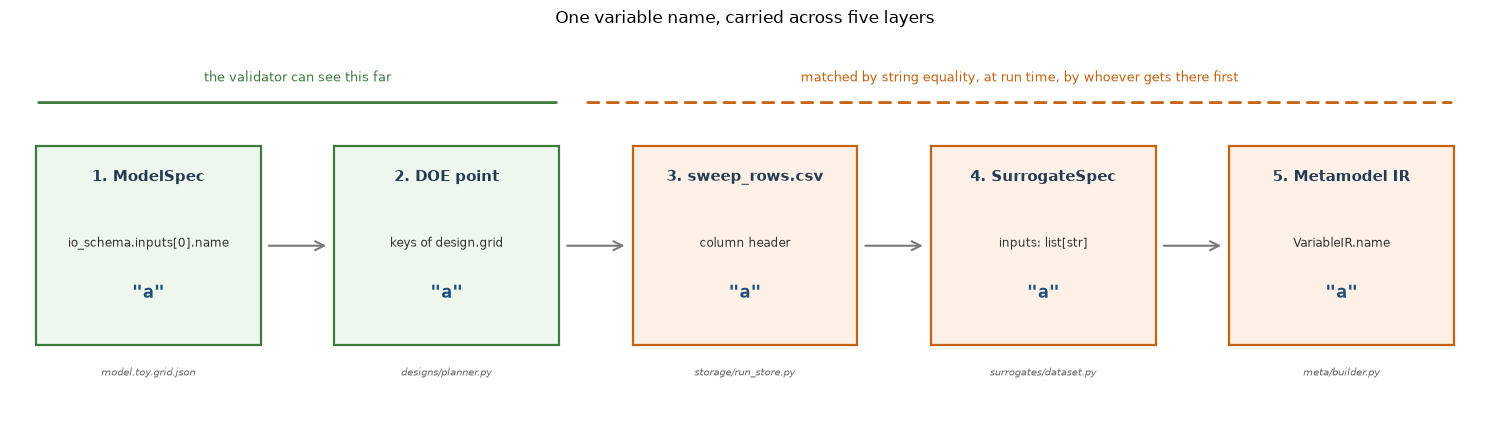

Rename the variable in one layer and the failure surfaces in the NEXT one -
as a KeyError (layer 3), as 'No successful rows found' (layer 4), or as a
coupling that silently refers to a variable nothing ever informs (layer 5).


In [13]:

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

LAYERS = [
    ("1. ModelSpec", "io_schema.inputs[0].name", "model.toy.grid.json"),
    ("2. DOE point", "keys of design.grid", "designs/planner.py"),
    ("3. sweep_rows.csv", "column header", "storage/run_store.py"),
    ("4. SurrogateSpec", "inputs: list[str]", "surrogates/dataset.py"),
    ("5. Metamodel IR", "VariableIR.name", "meta/builder.py"),
]

w, h, gap = 2.6, 1.6, 0.85
fig, ax = plt.subplots(figsize=(15, 4.4))

for i, (title, field, where) in enumerate(LAYERS):
    x = i * (w + gap)
    validated = i < 2
    ax.add_patch(Rectangle((x, 1.0), w, h,
                           facecolor="#eef7ee" if validated else "#fdf1e7",
                           edgecolor="#3d7a3d" if validated else "#c46210", linewidth=1.6))
    ax.text(x + w / 2, 1.0 + h - 0.25, title, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color="#243b53")
    ax.text(x + w / 2, 1.0 + h / 2 + 0.02, field, ha="center", va="center",
            fontsize=8.5, color="#333")
    ax.text(x + w / 2, 1.0 + 0.42, '"a"', ha="center", va="center", fontsize=13,
            fontweight="bold", color="#1f4e79", family="monospace")
    ax.text(x + w / 2, 0.78, where, ha="center", va="center", fontsize=7.5,
            style="italic", color="#666")
    if i:
        ax.add_patch(FancyArrowPatch((x - gap + 0.06, 1.0 + h / 2), (x - 0.06, 1.0 + h / 2),
                                     arrowstyle="->", mutation_scale=16,
                                     color="#7a7a7a", linewidth=1.5))

span = len(LAYERS) * (w + gap) - gap
bracket_end = 2 * w + gap
ax.add_patch(FancyArrowPatch((0.0, 2.95), (bracket_end, 2.95), arrowstyle="-",
                             mutation_scale=1, color="#3d7a3d", linewidth=2.0))
ax.text(bracket_end / 2, 3.12, "the validator can see this far", ha="center",
        fontsize=9.5, color="#3d7a3d")
ax.add_patch(FancyArrowPatch((bracket_end + 0.3, 2.95), (span, 2.95), arrowstyle="-",
                             mutation_scale=1, color="#c46210", linewidth=2.0,
                             linestyle=(0, (4, 3))))
ax.text((bracket_end + 0.3 + span) / 2, 3.12,
        "matched by string equality, at run time, by whoever gets there first",
        ha="center", fontsize=9.5, color="#c46210")

ax.set_xlim(-0.3, span + 0.3)
ax.set_ylim(0.4, 3.5)
ax.axis("off")
ax.set_title("One variable name, carried across five layers", fontsize=12, pad=8)
plt.tight_layout()
plt.show()

print("Rename the variable in one layer and the failure surfaces in the NEXT one -")
print("as a KeyError (layer 3), as 'No successful rows found' (layer 4), or as a")
print("coupling that silently refers to a variable nothing ever informs (layer 5).")



## One last failure worth recognizing on sight

`bayesmm validate` only ever applies `ModelSpec`. Point it at a *surrogate* spec and the
output is loud but confusing — unless you know the signature. This cell also shows the
`type` field that the CLI throws away, which is the machine-readable half of every error.


In [14]:

from collections import Counter

from pydantic import ValidationError

from bayesian_metamodeling.spec import load_and_validate_modelspec

rc_wrong_kind = run_mm_cli("validate", "tutorials/specs/surrogate.toy.pymc_gp.json", check=False)
print("exit code:", rc_wrong_kind)

# The same failure through the API, so we can see `type` — the field
# `format_validation_error` drops when it renders one line per error.
wrong_payload = json.loads((root / "tutorials/specs/surrogate.toy.pymc_gp.json").read_text())
try:
    load_and_validate_modelspec(wrong_payload)
    error_types = Counter()
except ValidationError as exc:
    error_types = Counter(item["type"] for item in exc.errors())

print("\nerror types:", dict(error_types))
print("`missing`         = a ModelSpec section this file does not have")
print("`extra_forbidden` = a key this file has that ModelSpec does not declare")


$ bayesmm validate tutorials/specs/surrogate.toy.pymc_gp.json
Spec validation failed:
- model: Field required
- runner: Field required
- io_schema: Field required
- design: Field required
- adapter: Field required
- reproducibility: Field required
- storage: Field required
- name: Extra inputs are not permitted
- kind: Extra inputs are not permitted
- inputs: Extra inputs are not permitted
- outputs: Extra inputs are not permitted
- backend: Extra inputs are not permitted
- backend_config: Extra inputs are not permitted
- dataset_ref: Extra inputs are not permitted
- seed: Extra inputs are not permitted
- summary_config: Extra inputs are not permitted
exit code: 1

error types: {'missing': 7, 'extra_forbidden': 9}
`missing`         = a ModelSpec section this file does not have
`extra_forbidden` = a key this file has that ModelSpec does not declare



## Troubleshooting

| Symptom | What it means | What to do |
|---|---|---|
| `- desgin: Extra inputs are not permitted` | A key `ModelSpec` does not declare — a typo, or a key that belongs one level down. | Every spec model sets `extra="forbid"` on purpose, so a typo fails loudly instead of being ignored. Check both the spelling *and* the nesting depth against the table above. |
| The path names a whole section (`- design: Value error, ...`) rather than the field you edited | The rule is a `model_validator(mode="after")` on that section, so Pydantic attributes it to the model, not to any one key. | Do not hunt for a field literally called `design`. The message names the real rule. Path depth tells you which kind of validator fired (Step 4). |
| `validate` passes, then `run` dies somewhere unrelated | You broke an unenforced cross-section contract (Step 5) or you are outside `support` (Step 6). | Run `bayesmm plan` first — it enumerates the DOE points without executing anything — and check the *keys* of the point it prints against `io_schema.inputs[*].name` yourself. |
| `DOE planning failed: design.grid values cannot be empty` | `validate` passed, because `{"a": []}` is a well-formed `dict[str, list[float]]`, and the *planner* refused. | Genuinely a planner-level check rather than a validator-level one — one more reason `plan` belongs between `validate` and `run`. (An entirely empty `grid: {}` is different: it is falsy, so `DesignSpec` rejects it as a missing config.) |
| A wall of `Field required` for sections you never intended to write, plus one `Extra inputs are not permitted` per key you did write | You pointed `validate` at the wrong **kind** of spec — see the cell above. | Surrogate specs go to `bayesmm surrogate fit`, metamodel specs to `bayesmm meta build`. `bayesmm validate` is `ModelSpec`-only. |



## Where this goes next

You can now read a validation error, jump to the path, and repair the JSON — and, just as
importantly, you know where the validator's authority stops. That combination is
load-bearing for the rest of the curriculum, because **every remaining tutorial is driven
by a spec you will edit**: T4 edits the `design` block, T5/T6 write surrogate specs, 7a-7c/T8
write metamodel specs whose `couplings` name variables by string.

Carry two habits forward:

- **Read the path before the message**, and let its depth tell you which kind of rule fired.
- **Run `plan` between `validate` and `run`.** It is free, and it is the only place the
  framework will show you the DOE points before it starts spending time on them.

**T4** is the natural next step: it changes exactly the block you just learned to debug —
`design` — and shows what a grid-versus-Sobol choice costs you in runs. The names in that
block are the same names Step 5 broke.



## Final check: every lesson in this notebook is still true

A weak self-check is how a tutorial rots. If the check only asserts that the last cell
wrote a file, a notebook whose exercises were quietly turned into no-ops still prints
`OK`. So this one re-derives each claim from scratch, in process, and asserts the
*outcome of the lesson*:

- the two catchable breaks were **rejected** (exit code `1`) and the two repairs
  **accepted** (exit code `0`);
- re-broken from scratch, the missing-section error still lands on the path `("design",)`
  and the inverted-support error on `("io_schema", "inputs", 0, "support")` — the specific
  claim Steps 2 and 4 make about *where* validators point;
- Step 5's `run` really did fail in the storage layer, after dispatching every point, and
  persisted nothing;
- the unenforced contracts are **still unenforced** — a renamed `design.grid` key and an
  out-of-support grid both still validate cleanly. If either of those assertions ever
  fails, that is good news about the framework and bad news about Steps 5 and 6: someone
  added a cross-section check, and those steps need rewriting.


In [15]:

# Self-check: T3's lessons, re-derived from scratch. Designed to fail on a notebook
# that ran end to end but taught nothing.
import copy
import json as _json

from pydantic import ValidationError as _VE

from bayesian_metamodeling.designs import plan_points as _plan_points
from bayesian_metamodeling.spec import load_and_validate_modelspec as _load

# --- 1) The catchable breaks were caught; the repairs repaired. -------------
assert rc_missing_grid == 1, f"Step 1's break must be REJECTED; validate returned {rc_missing_grid}."
assert rc_repair_grid == 0, f"Step 3's repair must be ACCEPTED; validate returned {rc_repair_grid}."
assert rc_inverted_support == 1, (
    f"Step 4's inverted support must be REJECTED; validate returned {rc_inverted_support}."
)
assert rc_repair_support == 0, (
    f"Step 4's repair must be ACCEPTED; validate returned {rc_repair_support}."
)

# --- 2) The scratch spec on disk is the repaired one, and it plans 9 points. -
_payload = _json.loads(SPEC.read_text())
_spec = _load(_payload)
assert _spec.io_schema.inputs[0].support == [0.0, 2.0], (
    f"After repair, support should be [0.0, 2.0]; got {_spec.io_schema.inputs[0].support}."
)
assert sorted(_spec.design.grid) == ["a", "b"], (
    f"After repair, design.grid should name a and b; got {sorted(_spec.design.grid)}."
)
_n_points = len(_plan_points(_spec))
assert _n_points == 9, f"The repaired 3x3 grid should plan 9 points; planned {_n_points}."

# --- 3) Re-break from scratch and assert WHERE the validator points. --------
def _locs_of(mutated: dict) -> list[tuple]:
    """Validate a payload that must fail, and return the reported error paths."""
    try:
        _load(mutated)
    except _VE as exc:
        return [item["loc"] for item in exc.errors()]
    return []


_no_grid = copy.deepcopy(_payload)
_no_grid["design"].pop("grid")
assert _locs_of(_no_grid) == [("design",)], (
    "Removing design.grid must fail with the path ('design',) — a model-level rule "
    f"blaming the section, not a leaf. Got {_locs_of(_no_grid)}."
)

_bad_support = copy.deepcopy(_payload)
_bad_support["io_schema"]["inputs"][0]["support"] = [2.0, 0.0]
assert _locs_of(_bad_support) == [("io_schema", "inputs", 0, "support")], (
    "An inverted support must fail with the full leaf path — a field-level rule. "
    f"Got {_locs_of(_bad_support)}."
)

# --- 4) Step 5 really failed late, in storage, and persisted nothing. -------
assert rc_mismatch_validate == 0 and rc_mismatch_plan == 0, (
    "Step 5's point: a renamed design.grid key passes BOTH validate and plan. Got "
    f"validate={rc_mismatch_validate}, plan={rc_mismatch_plan}."
)
assert isinstance(mismatch_exc, KeyError) and str(mismatch_exc) == "'a'", (
    "Step 5 claims `bayesmm run` dies with KeyError('a') in the storage layer. "
    f"Got {mismatch_exc!r}. If the framework now fails earlier and more clearly, "
    "Step 5 needs rewriting."
)
assert n_mismatch_sweeps == 0, (
    f"Step 5 claims the sweep is lost entirely; {n_mismatch_sweeps} sweep file(s) survived."
)

# --- 5) The unenforced contracts are still unenforced. ----------------------
_renamed = copy.deepcopy(_payload)
_renamed["design"]["grid"] = {"alpha": _payload["design"]["grid"]["a"],
                              "b": _payload["design"]["grid"]["b"]}
_outside = copy.deepcopy(_payload)
_outside["design"]["grid"] = {"a": [-500.0, 900.0], "b": [0.0]}
_unknown_adapter = copy.deepcopy(_payload)
_unknown_adapter["adapter"]["id"] = "no_such_adapter_v9"

for _label, _variant in (
    ("a renamed design.grid key", _renamed),
    ("a grid outside the declared support", _outside),
    ("an unknown adapter.id", _unknown_adapter),
):
    _locs = _locs_of(_variant)
    if _locs:
        raise AssertionError(
            f"{_label} now FAILS validation ({_locs}). Good news about the framework, "
            "bad news about this notebook: Steps 5-6 and the 'Why this matters' cell "
            "claim these are unchecked. Update them."
        )

assert rc_outside_validate == 0 and rc_outside_plan == 0, (
    "Step 6's point: a grid outside support passes validate AND plans points. Got "
    f"validate={rc_outside_validate}, plan={rc_outside_plan}."
)
assert rc_plan_ok == 0, f"plan on the repaired spec should succeed; got {rc_plan_ok}."
assert rc_wrong_kind == 1, (
    f"validate on a surrogate spec should fail (wrong kind of spec); got {rc_wrong_kind}."
)
assert error_types["missing"] >= 1 and error_types["extra_forbidden"] >= 1, (
    "The wrong-kind-of-spec signature is missing sections PLUS forbidden extras; "
    f"got {dict(error_types)}."
)

print(
    f"\n[T3 self-check OK] 2 breaks rejected at the right paths, 2 repairs accepted, "
    f"{_n_points} points planned from the repaired spec, and 3 cross-section contracts "
    f"still enforced by nobody."
)



[T3 self-check OK] 2 breaks rejected at the right paths, 2 repairs accepted, 9 points planned from the repaired spec, and 3 cross-section contracts still enforced by nobody.
